## __Week 6 Assignment: A/B Tests & Simple Linear Regression__

### __Topic 1: A/B Testing__

##### To implement A/B testing in Python, you primarily use `statsmodels` for frequentist tests (z-tests, t-tests) and `PyMC` for Bayesian analysis.

In [8]:
from statsmodels.stats.proportion import proportions_ztest

# Data: successes and total observations
count = [120, 145] # Conversions in Group A and B
nobs = [1000, 1000] # Total users in Group A and B

# Perform two-sided z-test
stat, p_value = proportions_ztest(count, nobs)

print(f"Z-statistic: {stat:.4f}, P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Statistically significant result.")

Z-statistic: -1.6489, P-value: 0.0992


### __Question 1:__ 
A company wants to test if a new "Buy Now" button color (version B) increases sign-ups compared to the results above (for version A). After the trial was completed the results for Group A and B were updated to the following: 

#### Version B:
- __In Group A:__ (1,000 users), 120 signed up. 
- __In Group B:__ (1,000 users), 150 signed up. 

Now, use the `proportions_ztest` code above to determine if this 3% difference, in sign ups, is statistically significant at a 95% confidence level and what this means for your hypothesis. Include in your answer the new output from the code block as well.

In [9]:
from statsmodels.stats.proportion import proportions_ztest

# Data: successes and total observations
count = [120, 150] # Conversions in Group A and B -- UPDATED conversions
nobs = [1000, 1000] # Total users in Group A and B

# Perform two-sided z-test
stat, p_value = proportions_ztest(count, nobs)

print(f"Z-statistic: {stat:.4f}, P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Statistically significant result.")

Z-statistic: -1.9630, P-value: 0.0496
Statistically significant result.


#### Q1 Response
The value is statistically significant, because the P-value is below 0.05 (5%) which is the limit for our 95% confidence level.

This means that we can reject the Null hypothesis that the change in button color did not affect sales, as this provides evidence pointing towards the Alternative hypothesis of button color changing sales being true.

### __Question 2:__
Can you explain the difference between a Type I error (false positive) and a Type II error (false negative) in the context of this test? 
- Extra points, if you can provide an explanation on the business impact each type would have in this scenario.

#### Q2 Response
Type I Error: This is a false positive. This means that we reject the null hypothesis of the button color not affecting sales, when in reality it did not affect sales.
- Business Impact: The company would change the button and project sales growth, but fail to meet estimates over time.

Type II Error: This is a false negative. This means that we do not reject the null hypothesis of the button color not affecting sales, when in reality it did affect sales.
- Business Impact: This would cause the company to miss out on additional sales that would be gained from changing the button color, but not affect sales projections.

### __Topic 2:__ Simple Linear Regression

Predicting how much a house costs based on its square footage.

In [10]:
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Data: Square footage (X) and House Price in thousands (y)
# X must be 2D: [[sqft1], [sqft2], ...]
X = np.array([[1000], [1500], [2000], [2500], [3000]])
y = np.array([200, 300, 400, 500, 600])

# 2. Initialize and Train the model
model = LinearRegression()
model.fit(X, y)

# 3. Predict the price for a 1800 sqft house
#new_house = np.array([[1800]])
new_house =([[1800]])
prediction = model.predict(new_house)

print(f"Predicted Price: ${prediction[0]:.3f}k")
print(f"R-squared Score: {model.score(X, y)}")


Predicted Price: $360.000k
R-squared Score: 1.0


### __Question 3:__
Swap X and y in the model.fit(X, y) line, would the code still run? What would the model be trying to predict then?

#### Q3 Response
The code would not run, because X is looking for "2D" data (as stated in the code comments), while y is a standard array. It would run if the data was modified. The new model would be attempting to predict the square footage of a house based on its price.

### __Question 4:__

How would you change the code to predict the prices for three different houses (1200, 2200, and 3500 sqft) all at once?

What is the new predicted price?

#### Q4 Response
You would simply put multiple houses (sqft values) into the `new_house` array.

I am confused by the wording, as three different houses would provide three different predicted prices. If we wanted one price (all the houses combined) we would do this by adding 1200, 2200, and 3500 together. The combined predicted price is $1,380k ($1.38m)

If we wanted to predict the prices for three different houses (three different prices, not one as the question states) you would add a for loop to iterate over the prediction.
The predicted prices are $360k, $440k, and $700k for 1200, 2200, and 3500 sqft respectively.

See code below:

In [11]:
## ADD TOGETHER
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Data: Square footage (X) and House Price in thousands (y)
# X must be 2D: [[sqft1], [sqft2], ...]
X = np.array([[1000], [1500], [2000], [2500], [3000]])
y = np.array([200, 300, 400, 500, 600])

# 2. Initialize and Train the model
model = LinearRegression()
model.fit(X, y)

# 3. Predict the price for a 1800 sqft house
#new_house = np.array([[1800]])
new_house =([[1200 + 2200 + 3500]])
prediction = model.predict(new_house)

print(f"Predicted Price: ${prediction[0]:.3f}k")
print(f"R-squared Score: {model.score(X, y)}")

Predicted Price: $1380.000k
R-squared Score: 1.0


In the below code block, in order to display multiple prices I added the other two values to the `new_house` array, created a for loop that goes through new house while enumerating the array, so the `prediction` variable can access the value found in the `model.predict()` function that corresponds to the specific sqft array value in `new_house`. I also added a print statement to mark which sqft value's data was being shown.

In [12]:
## 3 PRICES
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Data: Square footage (X) and House Price in thousands (y)
# X must be 2D: [[sqft1], [sqft2], ...]
X = np.array([[1000], [1500], [2000], [2500], [3000]])
y = np.array([200, 300, 400, 500, 600])

# 2. Initialize and Train the model
model = LinearRegression()
model.fit(X, y)

# 3. Predict the price for a 1800 sqft house
#new_house = np.array([[1800]])
new_house = ([[1800], [2200], [3500]])
prediction = model.predict(new_house)

for i in enumerate(new_house):
    print(f"{i[1][0]} sqft")
    print(f"Predicted Price: ${prediction[i[0]]:.3f}k")
    print(f"R-squared Score: {model.score(X, y)}")

1800 sqft
Predicted Price: $360.000k
R-squared Score: 1.0
2200 sqft
Predicted Price: $440.000k
R-squared Score: 1.0
3500 sqft
Predicted Price: $700.000k
R-squared Score: 1.0


### __Question 5:__

In the original code block the predicted house price for a 1800 sqft home was $360,000. This means the model discovered a perfect relationship (R^2 score = 1.0) where price = 0.2 x sqft or price = $200 per sqft.  

Now, add a house that is 5,000 sqft but only cost $100k (an outlier), how does this change the slope (line) this code creates? Compare the outputs for slope in your answer and how this is interpreted mathematically vs. in reality.

In [13]:
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Data: Square footage (X) and House Price in thousands (y)
# X must be 2D: [[sqft1], [sqft2], ...]
X = np.array([[1000], [1500], [2000], [2500],[3000]])
y = np.array([200, 300, 400, 500,600])

# (New Code): Add Outlier Data
X_outlier = np.append(X, [[5000]], axis=0) # <---- Answer needed
y_outlier = np.append(y, [100]) # <---- Answer needed

# 2. Initialize and Train the model
model = LinearRegression()
model.fit(X, y)

# (New Code): Intialize, Train, and Fit Outlier Model
model_outlier = LinearRegression().fit(X_outlier, y_outlier) # <---- Answer needed

# 3. Predict the price for a 1800 sqft house
#new_house = np.array([[1800]])
#new_house =([[1800]])
#prediction = model.predict(new_house)

# Results
#print(f"Original Predicted Price: ${prediction[0]:.3f}k")
#print(f"Original R-squared Score: {model.score(X, y)}")
print(f"Original Slope: ${model.coef_[0]:.2f}")
print(f"Outlier Slope: {model_outlier.coef_[0]:.2f}")

Original Slope: $0.20
Outlier Slope: -0.02


#### Q5 Response
This inverts the slope, turning it negative a (likely incorrect) assumption that higher square footage decreases the house price. With the original slope being 0.2 and the new slope being -0.02, this shows that even one outlier has entirely shifted this model's assumptions, meaning it is not susceptible and resilient against outliers.

In reality, this is almost certainly not the case, as higher square footage generally presents a higher asking price for a house.

#### __Hint:__ If you are stuck, run this code below to see a visual of the slopes.

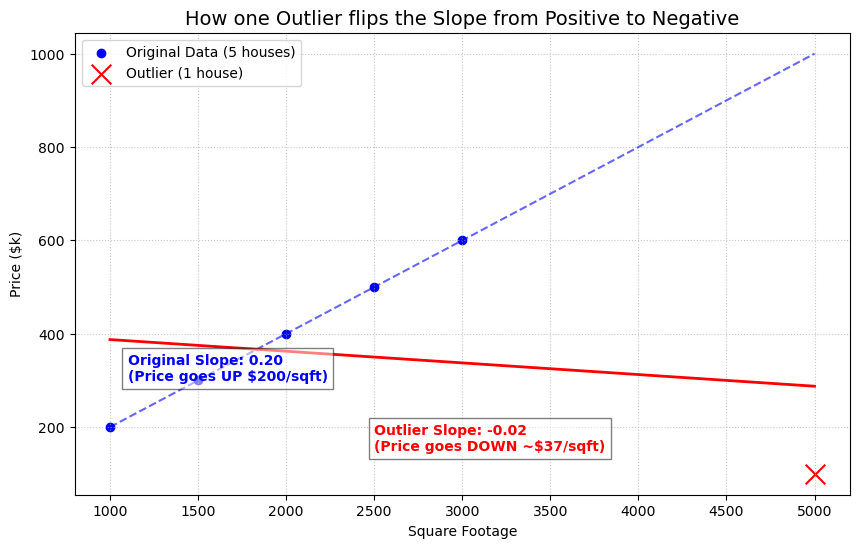

In [14]:
import matplotlib.pyplot as plt

# 1. Create a range for the lines
x_range = np.linspace(1000, 5000, 100).reshape(-1, 1)
y_line_orig = model.predict(x_range)
y_line_outlier = model_outlier.predict(x_range)

# 2. Extract the actual slope values from the models
slope_orig = model.coef_[0]
slope_outlier = model_outlier.coef_[0]

# 3. Create the plot
plt.figure(figsize=(10, 6))

# Plot data points
plt.scatter(X, y, color='blue', label='Original Data (5 houses)')
plt.scatter(X_outlier[-1], y_outlier[-1], color='red', marker='x', s=200, label='Outlier (1 house)')

# Plot regression lines
plt.plot(x_range, y_line_orig, color='blue', linestyle='--', alpha=0.6)
plt.plot(x_range, y_line_outlier, color='red', linewidth=2)

# 4. Display the Slopes as Text on the Graph
# Positioning the text near the start of the lines
plt.text(1100, 300, f"Original Slope: {slope_orig:.2f}\n(Price goes UP $200/sqft)", 
         color='blue', fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))

plt.text(2500, 150, f"Outlier Slope: {slope_outlier:.2f}\n(Price goes DOWN ~$37/sqft)", 
         color='red', fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))

# Formatting
plt.title("How one Outlier flips the Slope from Positive to Negative", fontsize=14)
plt.xlabel("Square Footage")
plt.ylabel("Price ($k)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()